<a href="https://colab.research.google.com/github/chandrababu511/my-first-repo/blob/master/B2_EDA_workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


In [8]:
df = pd.read_csv("/content/zomato.csv", on_bad_lines='skip', engine='python')
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51155 entries, 0 to 51154
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51155 non-null  object
 1   address                      51155 non-null  object
 2   name                         51155 non-null  object
 3   online_order                 51155 non-null  object
 4   book_table                   51155 non-null  object
 5   rate                         43380 non-null  object
 6   votes                        51155 non-null  int64 
 7   phone                        49952 non-null  object
 8   location                     51134 non-null  object
 9   rest_type                    50931 non-null  object
 10  dish_liked                   23081 non-null  object
 11  cuisines                     51110 non-null  object
 12  approx_cost(for two people)  50811 non-null  object
 13  reviews_list                 51

In [10]:
df[['name', 'online_order', 'book_table', 'rate', 'votes',
    'location', 'rest_type', 'cuisines', 'approx_cost(for two people)']].head(10)

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people)
0,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800
1,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800
2,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,"South Indian, North Indian",300
4,Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600
5,Timepass Dinner,Yes,No,3.8/5,286,Basavanagudi,Casual Dining,North Indian,600
6,Rosewood International Hotel - Bar & Restaurant,No,No,3.6/5,8,Mysore Road,Casual Dining,"North Indian, South Indian, Andhra, Chinese",800
7,Onesta,Yes,Yes,4.6/5,2556,Banashankari,"Casual Dining, Cafe","Pizza, Cafe, Italian",600
8,Penthouse Cafe,Yes,No,4.0/5,324,Banashankari,Cafe,"Cafe, Italian, Continental",700
9,Smacznego,Yes,No,4.2/5,504,Banashankari,Cafe,"Cafe, Mexican, Italian, Momos, Beverages",550


In [11]:
for col in df.columns:
    missing = df[col].isnull().sum()
    pct = missing / len(df) * 100
    print(f"{col}.     {pct:1f}")

url.     0.000000
address.     0.000000
name.     0.000000
online_order.     0.000000
book_table.     0.000000
rate.     15.198905
votes.     0.000000
phone.     2.351676
location.     0.041052
rest_type.     0.437885
dish_liked.     54.880266
cuisines.     0.087968
approx_cost(for two people).     0.672466
reviews_list.     0.000000
menu_item.     0.000000
listed_in(type).     0.000000
listed_in(city).     0.000000


In [12]:
df['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', nan, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '-', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '2.4 /5', '4.7 /5',
       '2.2 /5', '2.0 /5', '2.1 /5', '1.8 /5'], dtype=object)

# NEW, _ , NAN. -- Hanlde
# Remove /5
# Convert everyhting to float

In [15]:
df['rating'] = df['rate'].str.replace('/5', "", regex = False) # Just removing the /5
df['rating']

,rating
0,4.1
1,4.1
2,3.8
3,3.7
4,3.8
...,...
51150,3.6
51151,NaN
51152,NaN
51153,4.3


In [17]:
df['rating'] = df['rating'].replace(['NEW', '-'], np.nan)
df['rating'] = pd.to_numeric(df['rating'], errors = 'coerce')

df['rating']

,rating
0,4.1
1,4.1
2,3.8
3,3.7
4,3.8
...,...
51150,3.6
51151,NaN
51152,NaN
51153,4.3


In [18]:
df['rating'].describe()

,rating
count,41105.000000
mean,3.694088
std,0.435111
min,1.800000
25%,3.400000
50%,3.700000
75%,4.000000
max,4.900000


In [19]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)', 'rating'],
      dtype='object')

In [24]:
df['approx_cost(for two people)'].value_counts().head(15)

,count
approx_cost(for two people),
300,7561
400,6540
500,4952
200,4856
600,3664
250,2959
800,2265
150,2062
700,1925


In [27]:
df['cost_for_two'] = df['approx_cost(for two people)'].replace(",", "")

df['cost_for_two'] = pd.to_numeric(df['cost_for_two'], errors='coerce')
df['cost_for_two'].describe()

,cost_for_two
count,44236.000000
mean,415.763744
std,194.251448
min,40.000000
25%,300.000000
50%,400.000000
75%,500.000000
max,950.000000


In [28]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)', 'rating', 'cost_for_two'],
      dtype='object')

In [29]:
df['cuisines']

,cuisines
0,"North Indian, Mughlai, Chinese"
1,"Chinese, North Indian, Thai"
2,"Cafe, Mexican, Italian"
3,"South Indian, North Indian"
4,"North Indian, Rajasthani"
...,...
51150,Continental
51151,Finger Food
51152,Finger Food
51153,Finger Food


In [30]:
df['cuisine_count'] = df['cuisines'].str.split(",").str.len()
df[['cuisines','cuisine_count']].head(10)

,cuisines,cuisine_count
0,"North Indian, Mughlai, Chinese",3.0
1,"Chinese, North Indian, Thai",3.0
2,"Cafe, Mexican, Italian",3.0
3,"South Indian, North Indian",2.0
4,"North Indian, Rajasthani",2.0
5,North Indian,1.0
6,"North Indian, South Indian, Andhra, Chinese",4.0
7,"Pizza, Cafe, Italian",3.0
8,"Cafe, Italian, Continental",3.0
9,"Cafe, Mexican, Italian, Momos, Beverages",5.0


In [31]:
df['cuisine_count'].describe()

,cuisine_count
count,51110.000000
mean,2.444179
std,1.265235
min,1.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,8.000000


In [32]:
df['primary_cuisine'] = df['cuisines'].str.split(",").str[0]
df[['cuisines','cuisine_count','primary_cuisine']].head(10)

,cuisines,cuisine_count,primary_cuisine
0,"North Indian, Mughlai, Chinese",3.0,North Indian
1,"Chinese, North Indian, Thai",3.0,Chinese
2,"Cafe, Mexican, Italian",3.0,Cafe
3,"South Indian, North Indian",2.0,South Indian
4,"North Indian, Rajasthani",2.0,North Indian
5,North Indian,1.0,North Indian
6,"North Indian, South Indian, Andhra, Chinese",4.0,North Indian
7,"Pizza, Cafe, Italian",3.0,Pizza
8,"Cafe, Italian, Continental",3.0,Cafe
9,"Cafe, Mexican, Italian, Momos, Beverages",5.0,Cafe


In [33]:
df['primary_cuisine'].value_counts()

,count
primary_cuisine,
North Indian,12171
South Indian,5004
Cafe,4236
Chinese,3054
Biryani,3042
...,...
Iranian,4
Indonesian,3
Charcoal Chicken,3


In [34]:
df

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,...,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city),rating,cost_for_two,cuisine_count,primary_cuisine
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,...,"North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari,4.1,800.0,3.0,North Indian
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,...,"Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari,4.1,800.0,3.0,Chinese
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining",...,"Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari,3.8,800.0,3.0,Cafe
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,...,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari,3.7,300.0,2.0,South Indian
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,...,"North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari,3.8,600.0,2.0,North Indian
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51150,https://www.zomato.com/bangalore/best-brews-fo...,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,080 40301477,Whitefield,Bar,...,Continental,"1,500","[('Rated 5.0', ""RATED\n Food and service are ...",[],Pubs and bars,Whitefield,3.6,NaN,1.0,Continental
51151,https://www.zomato.com/bangalore/vinod-bar-and...,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,NaN,0,+91 8197675843,Whitefield,Bar,...,Finger Food,600,[],[],Pubs and bars,Whitefield,NaN,600.0,1.0,Finger Food
51152,https://www.zomato.com/bangalore/plunge-sherat...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,NaN,Whitefield,Bar,...,Finger Food,"2,000",[],[],Pubs and bars,Whitefield,NaN,NaN,1.0,Finger Food
51153,https://www.zomato.com/bangalore/chime-sherato...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,080 49652769,"ITPL Main Road, Whitefield",Bar,...,Finger Food,"2,500","[('Rated 4.0', 'RATED\n Nice and friendly pla...",[],Pubs and bars,Whitefield,4.3,NaN,1.0,Finger Food


In [35]:
df = df.dropna(subset = ['rating']).copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41105 entries, 0 to 51154
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   url                          41105 non-null  object 
 1   address                      41105 non-null  object 
 2   name                         41105 non-null  object 
 3   online_order                 41105 non-null  object 
 4   book_table                   41105 non-null  object 
 5   rate                         41105 non-null  object 
 6   votes                        41105 non-null  int64  
 7   phone                        40296 non-null  object 
 8   location                     41105 non-null  object 
 9   rest_type                    40959 non-null  object 
 10  dish_liked                   22906 non-null  object 
 11  cuisines                     41094 non-null  object 
 12  approx_cost(for two people)  40860 non-null  object 
 13  reviews_list         

In [41]:
df_rated = df.dropna(subset = ['rating']).copy()
df_rated.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41105 entries, 0 to 51154
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   url                          41105 non-null  object 
 1   address                      41105 non-null  object 
 2   name                         41105 non-null  object 
 3   online_order                 41105 non-null  object 
 4   book_table                   41105 non-null  object 
 5   rate                         41105 non-null  object 
 6   votes                        41105 non-null  int64  
 7   phone                        40296 non-null  object 
 8   location                     41105 non-null  object 
 9   rest_type                    40959 non-null  object 
 10  dish_liked                   22906 non-null  object 
 11  cuisines                     41094 non-null  object 
 12  approx_cost(for two people)  40860 non-null  object 
 13  reviews_list         

(array([3.000e+00, 2.700e+01, 2.600e+01, 1.180e+02, 9.400e+01, 5.550e+02,
        5.990e+02, 1.823e+03, 1.558e+03, 4.176e+03, 5.244e+03, 3.312e+03,
        7.654e+03, 3.952e+03, 6.076e+03, 2.140e+03, 2.677e+03, 5.940e+02,
        3.780e+02, 9.900e+01]),
 array([1.8  , 1.955, 2.11 , 2.265, 2.42 , 2.575, 2.73 , 2.885, 3.04 ,
        3.195, 3.35 , 3.505, 3.66 , 3.815, 3.97 , 4.125, 4.28 , 4.435,
        4.59 , 4.745, 4.9  ]),
 <BarContainer object of 20 artists>)

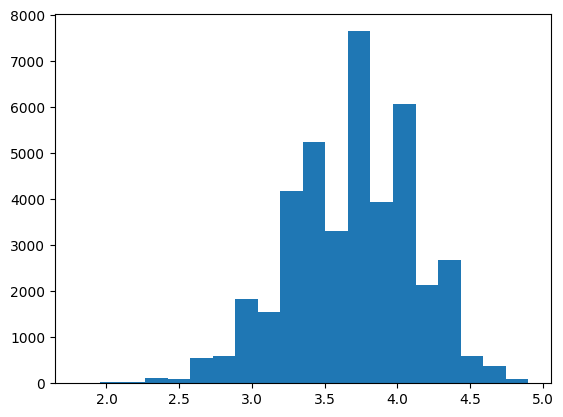

In [39]:
plt.hist(df['rating'], bins = 20)


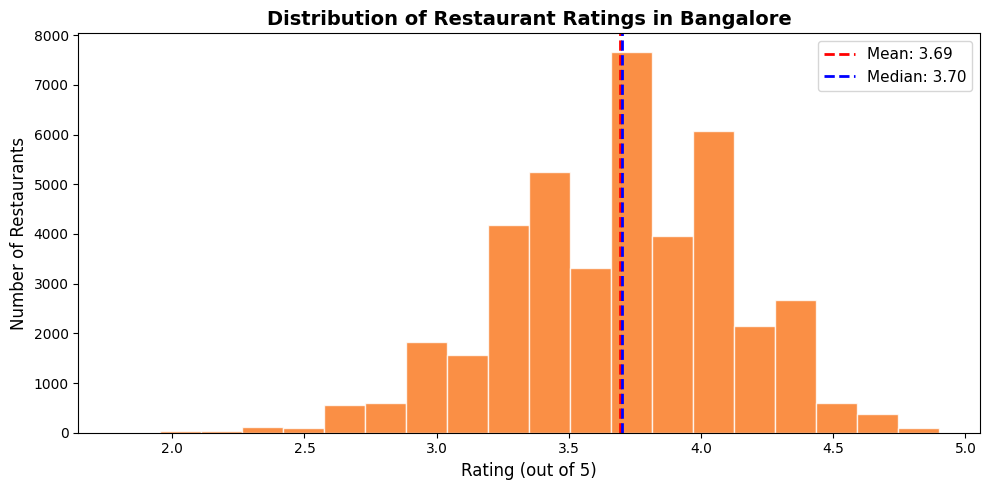

In [42]:
# Rating distribution
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df_rated['rating'], bins=20, color='#f97316', edgecolor='white', alpha=0.8)
ax.axvline(df_rated['rating'].mean(), color='red', linestyle='--', lw=2,
           label=f"Mean: {df_rated['rating'].mean():.2f}")
ax.axvline(df_rated['rating'].median(), color='blue', linestyle='--', lw=2,
           label=f"Median: {df_rated['rating'].median():.2f}")

ax.set_xlabel("Rating (out of 5)", fontsize=12)
ax.set_ylabel("Number of Restaurants", fontsize=12)
ax.set_title("Distribution of Restaurant Ratings in Bangalore", fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

(array([1.400e+01, 1.000e+00, 1.000e+00, 6.370e+02, 1.000e+01, 0.000e+00,
        1.309e+03, 1.700e+01, 3.176e+03, 0.000e+00, 1.200e+01, 2.134e+03,
        0.000e+00, 0.000e+00, 5.255e+03, 4.000e+00, 0.000e+00, 1.354e+03,
        0.000e+00, 5.268e+03, 0.000e+00, 0.000e+00, 1.217e+03, 0.000e+00,
        0.000e+00, 4.081e+03, 0.000e+00, 0.000e+00, 7.040e+02, 0.000e+00,
        3.160e+03, 0.000e+00, 0.000e+00, 7.430e+02, 0.000e+00, 0.000e+00,
        1.804e+03, 0.000e+00, 0.000e+00, 7.380e+02, 0.000e+00, 2.059e+03,
        0.000e+00, 0.000e+00, 1.460e+02, 0.000e+00, 0.000e+00, 6.420e+02,
        0.000e+00, 6.000e+01]),
 array([ 40. ,  58.2,  76.4,  94.6, 112.8, 131. , 149.2, 167.4, 185.6,
        203.8, 222. , 240.2, 258.4, 276.6, 294.8, 313. , 331.2, 349.4,
        367.6, 385.8, 404. , 422.2, 440.4, 458.6, 476.8, 495. , 513.2,
        531.4, 549.6, 567.8, 586. , 604.2, 622.4, 640.6, 658.8, 677. ,
        695.2, 713.4, 731.6, 749.8, 768. , 786.2, 804.4, 822.6, 840.8,
        859. , 877.2,

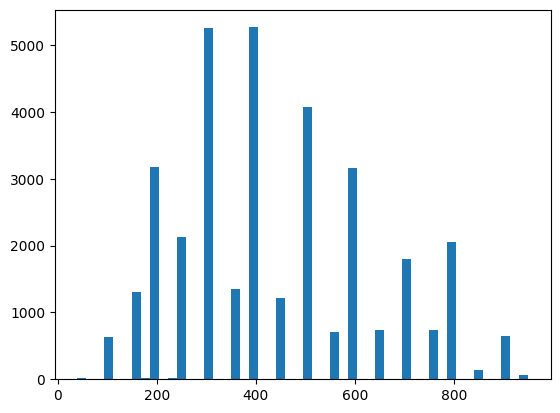

In [43]:
plt.hist(df['cost_for_two'], bins=50)

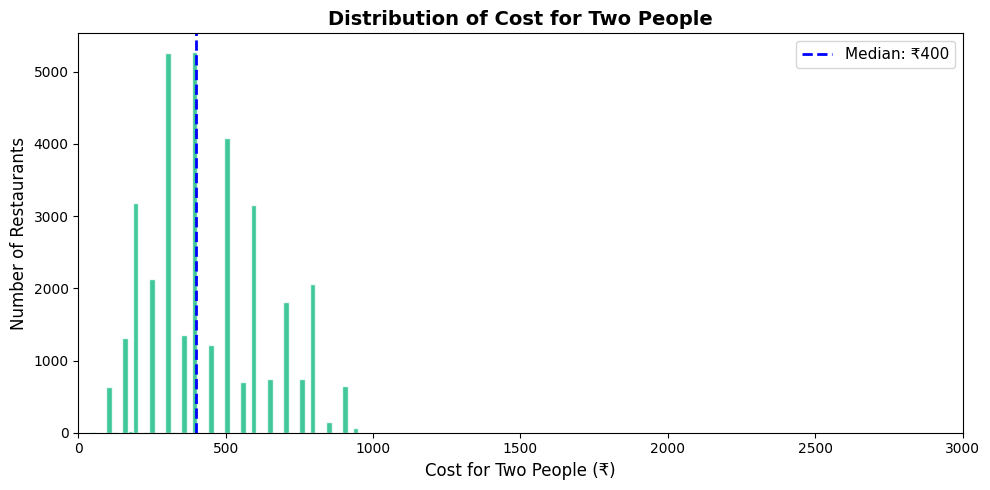

In [44]:
# Cost distribution
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df_rated['cost_for_two'].dropna(), bins=50, color='#10b981', edgecolor='white', alpha=0.8)
ax.axvline(df_rated['cost_for_two'].median(), color='blue', linestyle='--', lw=2,
           label=f"Median: ₹{df_rated['cost_for_two'].median():.0f}")
ax.set_xlabel("Cost for Two People (₹)", fontsize=12)
ax.set_ylabel("Number of Restaurants", fontsize=12)
ax.set_title("Distribution of Cost for Two People", fontsize=14, fontweight='bold')
ax.set_xlim(0, 3000)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [45]:
df_rated['online_order'].value_counts()

,count
online_order,
Yes,26914
No,14191


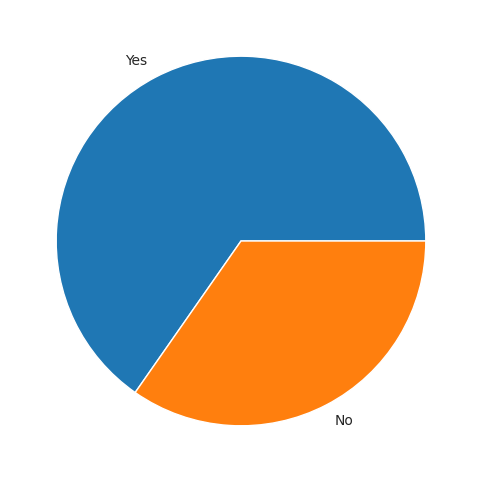

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

data = [27206, 14459] # Sample data # yes or no
labels = ["Yes" , "No"] # Labels for each slice # Numbers - The value counts

sns.set_style("whitegrid") # Set style for chart
plt.figure(figsize=(6,6)) # Set figure size
plt.pie(data, labels=labels) # Create pie chart
plt.show() # Show chart

In [47]:
df_rated

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,...,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city),rating,cost_for_two,cuisine_count,primary_cuisine
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,...,"North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari,4.1,800.0,3.0,North Indian
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,...,"Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari,4.1,800.0,3.0,Chinese
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining",...,"Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari,3.8,800.0,3.0,Cafe
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,...,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari,3.7,300.0,2.0,South Indian
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,...,"North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari,3.8,600.0,2.0,North Indian
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51147,https://www.zomato.com/bangalore/the-farm-hous...,"136, SAP Labs India, KIADB Export Promotion In...",The Farm House Bar n Grill,No,No,3.7 /5,34,+91 9980121279\n+91 9900240646,Whitefield,"Casual Dining, Bar",...,"North Indian, Continental",800,"[('Rated 4.0', 'RATED\n Ambience- Big and spa...",[],Pubs and bars,Whitefield,3.7,800.0,2.0,North Indian
51149,https://www.zomato.com/bangalore/bhagini-2-whi...,"139/C1, Next To GR Tech Park, Pattandur Agraha...",Bhagini,No,No,2.5 /5,81,080 65951222,Whitefield,"Casual Dining, Bar",...,"Andhra, South Indian, Chinese, North Indian",800,"[('Rated 4.0', 'RATED\n A fine place to chill...",[],Pubs and bars,Whitefield,2.5,800.0,4.0,Andhra
51150,https://www.zomato.com/bangalore/best-brews-fo...,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,080 40301477,Whitefield,Bar,...,Continental,"1,500","[('Rated 5.0', ""RATED\n Food and service are ...",[],Pubs and bars,Whitefield,3.6,NaN,1.0,Continental
51153,https://www.zomato.com/bangalore/chime-sherato...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,080 49652769,"ITPL Main Road, Whitefield",Bar,...,Finger Food,"2,500","[('Rated 4.0', 'RATED\n Nice and friendly pla...",[],Pubs and bars,Whitefield,4.3,NaN,1.0,Finger Food


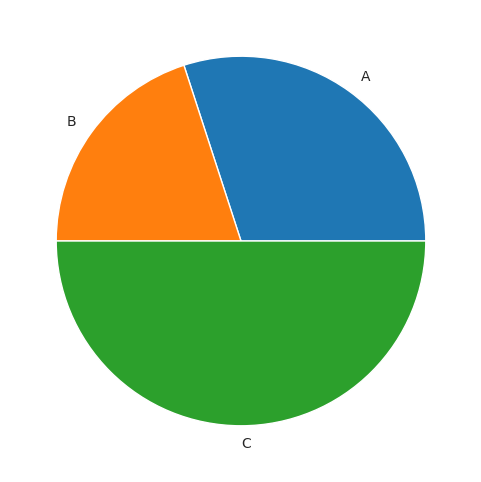

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

data = [30, 20, 50] # Sample data # yes or no
labels = ['A', 'B', 'C'] # Labels for each slice # Numbers - The value counts

sns.set_style("whitegrid") # Set style for chart
plt.figure(figsize=(6,6)) # Set figure size
plt.pie(data, labels=labels) # Create pie chart
plt.show() # Show chart

In [49]:
df_rated['rest_type'].value_counts()

,count
rest_type,
Quick Bites,13913
Casual Dining,9538
Cafe,3344
Dessert Parlor,1854
Delivery,1669
...,...
"Bakery, Food Court",2
"Dessert Parlor, Food Court",2
"Food Court, Beverage Shop",2


<Axes: ylabel='rest_type'>

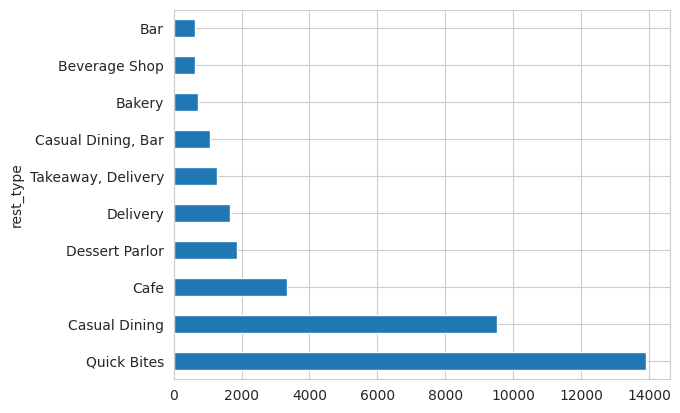

In [51]:
df['rest_type'].value_counts().head(10).plot.barh()

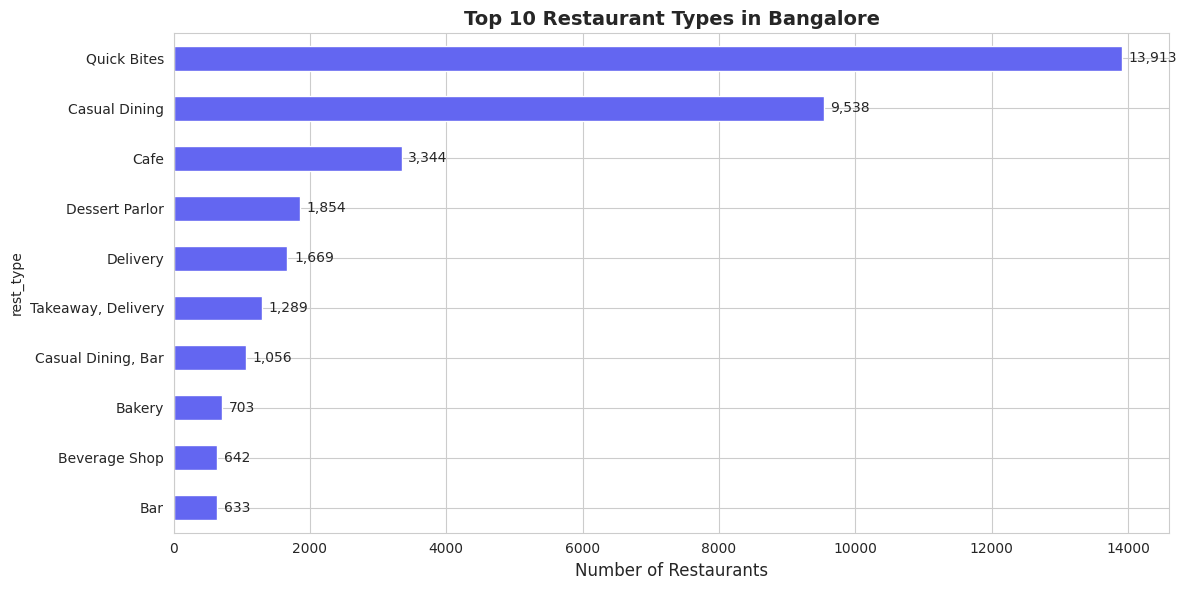

In [52]:
# Top restaurant types
fig, ax = plt.subplots(figsize=(12, 6))
top_types = df['rest_type'].value_counts().head(10)
top_types.plot.barh(ax=ax, color='#6366f1', edgecolor='white')
ax.set_xlabel("Number of Restaurants", fontsize=12)
ax.set_title("Top 10 Restaurant Types in Bangalore", fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add value labels
for i, v in enumerate(top_types.values):
    ax.text(v + 100, i, f"{v:,}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

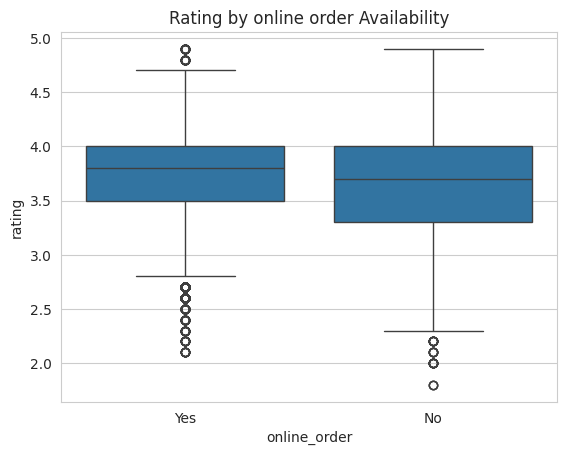

In [53]:
sns.boxplot(data = df_rated, x = "online_order", y = 'rating')
plt.title("Rating by online order Availability")
plt.show()

In [54]:
df_rated.groupby("online_order")['rating'].mean()

,rating
online_order,
No,3.650701
Yes,3.716965


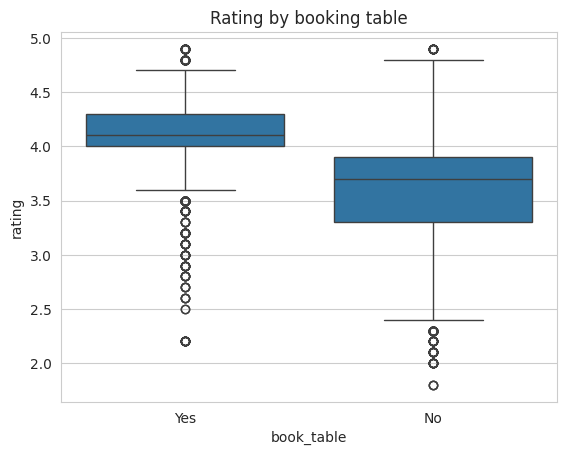

In [55]:
sns.boxplot(data = df_rated, x = "book_table", y = 'rating')
plt.title("Rating by booking table")
plt.show()

In [56]:
df[['cost_for_two', 'rating']]

,cost_for_two,rating
0,800.0,4.1
1,800.0,4.1
2,800.0,3.8
3,300.0,3.7
4,600.0,3.8
...,...,...
51147,800.0,3.7
51149,800.0,2.5
51150,NaN,3.6
51153,NaN,4.3


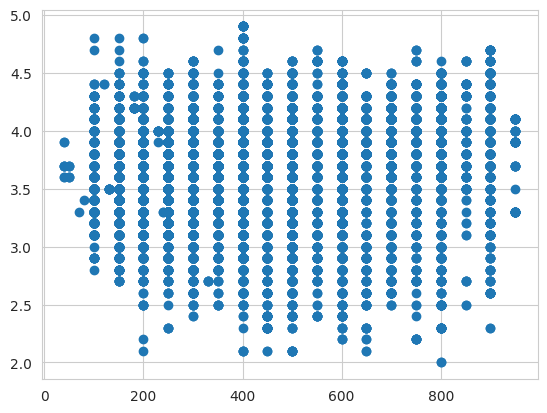

In [57]:
plt.scatter(df_rated['cost_for_two'], df_rated['rating'])

<Axes: xlabel='cost_for_two', ylabel='rating'>

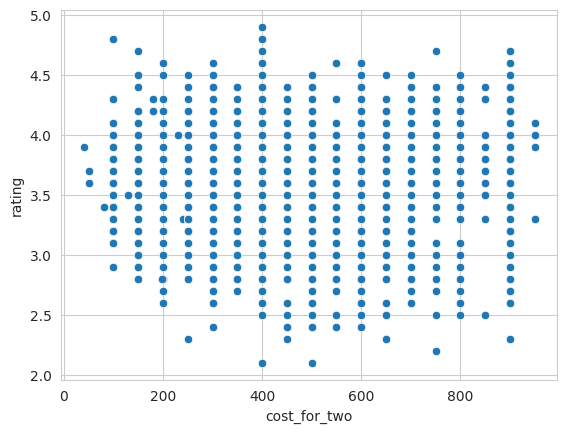

In [58]:
# try to randomly take a sample of data
sample = df_rated.dropna(subset=['cost_for_two']).sample(5000, random_state = 42)
sns.scatterplot(sample, x ='cost_for_two', y = "rating" )

In [59]:
df_rated[['cost_for_two', 'rating']].corr()

,cost_for_two,rating
cost_for_two,1.000000,0.193152
rating,0.193152,1.000000


In [60]:
df_rated.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)', 'rating', 'cost_for_two',
       'cuisine_count', 'primary_cuisine'],
      dtype='object')

In [61]:
top_10_locs = df_rated['location'].value_counts().head(10).index
top_10_locs

Index(['BTM', 'Koramangala 5th Block', 'HSR', 'Indiranagar', 'JP Nagar',
       'Jayanagar', 'Whitefield', 'Marathahalli', 'Bannerghatta Road',
       'Koramangala 6th Block'],
      dtype='object', name='location')

In [63]:
loc_ratings = df_rated[df_rated['location'].isin(top_10_locs)].groupby("location")['rating'].mean().sort_values()
loc_ratings

,rating
location,
Bannerghatta Road,3.506031
Marathahalli,3.531400
BTM,3.573801
Whitefield,3.614185
HSR,3.669596
JP Nagar,3.674824
Koramangala 6th Block,3.774039
Jayanagar,3.778606
Indiranagar,3.822894


<Axes: ylabel='location'>

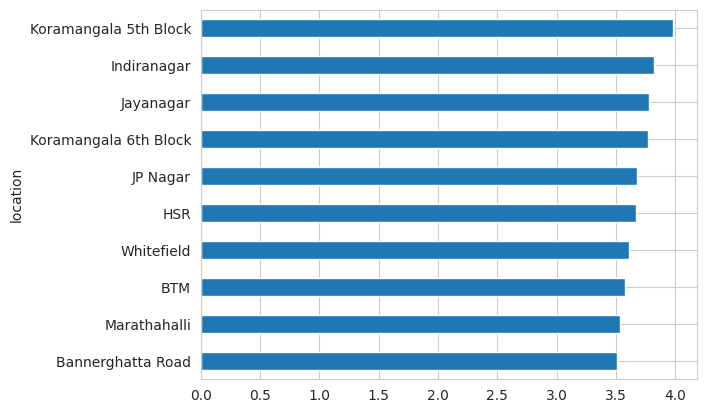

In [64]:
loc_ratings.plot.barh()